# Assignment 7: Feature Engineering for Phantom Classification (No Neural Networks)

## Summary

**Task:** Perform feature engineering on the random phantom images from A6. Normalize and extract histograms to significantly reduce data size. Find a method **without using neural networks** that achieves similar performance to A6's CNN (99.3% accuracy).

**Approach:**
- Reuse the phantom generator from A6 (same dataset)
- Extract a compact feature vector (~31 features) from each 28x28 image (784 pixels → 31 features = 25x reduction)
- Features include: intensity histograms, connected component counts, image statistics, and edge features
- Train SVM and Random Forest classifiers

**Result:** Traditional ML with engineered features achieves comparable accuracy to the CNN, with significantly reduced data dimensionality.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.stats import skew, kurtosis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Phantom Generator (from A6)

In [2]:
def phantom(n=256, ellipses=None):
    """
    Create a phantom image from a set of ellipses.
    Each ellipse: [I, a, b, x0, y0, phi]
    """
    p = np.zeros((n, n))
    ygrid, xgrid = np.mgrid[-1:1:(1j*n), -1:1:(1j*n)]

    for ellip in ellipses:
        I   = ellip[0]
        a2  = ellip[1]**2
        b2  = ellip[2]**2
        x0  = ellip[3]
        y0  = ellip[4]
        phi = ellip[5] * np.pi / 180

        x = xgrid - x0
        y = ygrid - y0

        cos_p = np.cos(phi)
        sin_p = np.sin(phi)

        locs = (((x * cos_p + y * sin_p)**2) / a2
              + ((y * cos_p - x * sin_p)**2) / b2) <= 1

        p[locs] += I

    return p

def random_ellipse():
    """Generate parameters for one random ellipse."""
    I   = np.random.uniform(0.3, 1.0)
    a   = np.random.uniform(0.15, 0.5)
    b   = np.random.uniform(0.10, 0.4)
    x0  = np.random.uniform(-0.4, 0.4)
    y0  = np.random.uniform(-0.4, 0.4)
    phi = np.random.uniform(0, 180)
    return [I, a, b, x0, y0, phi]

def generate_phantom(num_ellipses, img_size=28):
    """Generate a single phantom with the given number of ellipses."""
    ellipses = [random_ellipse() for _ in range(num_ellipses)]
    P = phantom(n=img_size, ellipses=ellipses)
    P = np.maximum(0, P)
    if P.max() > 0:
        P = P / P.max()
    return P

def generate_dataset(num_per_class, img_size=28):
    """Generate a dataset of one-ellipse and two-ellipse phantoms."""
    images = []
    labels = []

    for _ in range(num_per_class):
        images.append(generate_phantom(1, img_size))
        labels.append(0)

    for _ in range(num_per_class):
        images.append(generate_phantom(2, img_size))
        labels.append(1)

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.float32)

    idx = np.random.permutation(len(labels))
    return images[idx], labels[idx]

## Generate Dataset (same as A6)

In [3]:
np.random.seed(42)

train_images, train_labels = generate_dataset(2000, img_size=28)
test_images, test_labels = generate_dataset(500, img_size=28)

print(f"Training set: {train_images.shape}, labels: {train_labels.shape}")
print(f"Test set:     {test_images.shape}, labels: {test_labels.shape}")

Training set: (4000, 28, 28), labels: (4000,)
Test set:     (1000, 28, 28), labels: (1000,)


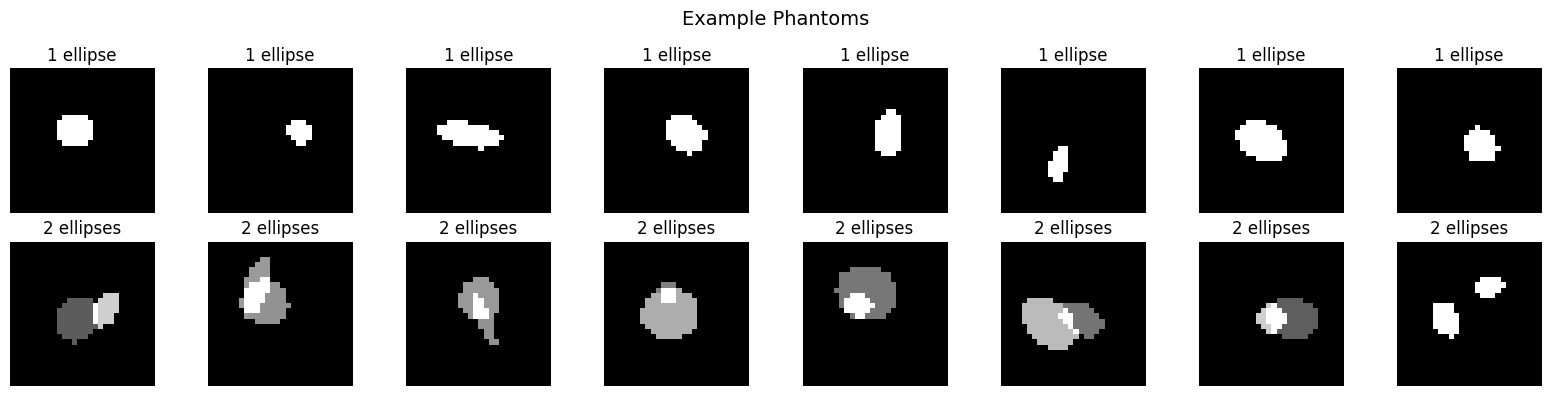

In [4]:
# Show example phantoms
one_idx = np.where(train_labels == 0)[0]
two_idx = np.where(train_labels == 1)[0]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Example Phantoms', fontsize=14)

for i in range(8):
    axes[0, i].imshow(train_images[one_idx[i]], cmap='Greys_r', vmin=0, vmax=1)
    axes[0, i].set_title('1 ellipse')
    axes[0, i].axis('off')

    axes[1, i].imshow(train_images[two_idx[i]], cmap='Greys_r', vmin=0, vmax=1)
    axes[1, i].set_title('2 ellipses')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## Feature Engineering

Extract a compact feature vector from each 28x28 image. The features capture properties that distinguish 1-ellipse from 2-ellipse phantoms:

1. **Intensity histogram** (16 bins) — captures the shape of the pixel value distribution
2. **Bright pixel counts** at multiple thresholds — 2 ellipses cover more area
3. **Connected components** at multiple thresholds — directly counts distinct bright regions
4. **Image statistics** (mean, std, skewness, kurtosis) — distribution shape measures
5. **Edge pixel count** (Sobel filter) — 2 ellipses produce more edges
6. **Spatial variance** of bright pixel locations — separated ellipses spread the mass

In [5]:
def extract_features(image):
    """Extract a feature vector from a 28x28 phantom image."""
    features = []

    # 1. Intensity histogram (16 bins, normalized)
    hist, _ = np.histogram(image, bins=16, range=(0, 1))
    hist = hist / hist.sum()  # Normalize to probability
    features.extend(hist)  # 16 features

    # 2. Bright pixel counts at different thresholds
    for thresh in [0.05, 0.1, 0.3]:
        features.append(np.sum(image > thresh) / image.size)  # Fraction of bright pixels
    # 3 features

    # 3. Connected components at different thresholds
    for thresh in [0.05, 0.1, 0.2]:
        binary = image > thresh
        labeled, num_components = ndimage.label(binary)
        features.append(num_components)
    # 3 features

    # 4. Image statistics
    features.append(np.mean(image))
    features.append(np.std(image))
    features.append(skew(image.ravel()))
    features.append(kurtosis(image.ravel()))
    # 4 features

    # 5. Statistics of non-zero pixels only
    nonzero = image[image > 0.01]
    if len(nonzero) > 0:
        features.append(np.mean(nonzero))
        features.append(np.std(nonzero))
    else:
        features.append(0.0)
        features.append(0.0)
    # 2 features

    # 6. Edge features (Sobel filter)
    edges_x = ndimage.sobel(image, axis=0)
    edges_y = ndimage.sobel(image, axis=1)
    edge_magnitude = np.sqrt(edges_x**2 + edges_y**2)
    features.append(np.sum(edge_magnitude > 0.1) / image.size)  # Fraction of edge pixels
    features.append(np.mean(edge_magnitude))  # Mean edge strength
    # 2 features

    # 7. Spatial variance of bright pixels
    bright_mask = image > 0.1
    if np.sum(bright_mask) > 1:
        rows, cols = np.where(bright_mask)
        features.append(np.var(rows))  # Vertical spread
        features.append(np.var(cols))  # Horizontal spread
    else:
        features.append(0.0)
        features.append(0.0)
    # 2 features

    return np.array(features, dtype=np.float32)

# Test on one image
sample_features = extract_features(train_images[0])
print(f"Feature vector length: {len(sample_features)}")
print(f"Data reduction: {28*28} pixels -> {len(sample_features)} features ({28*28 / len(sample_features):.1f}x reduction)")

Feature vector length: 32
Data reduction: 784 pixels -> 32 features (24.5x reduction)


In [6]:
# Extract features for all images
print("Extracting training features...")
train_features = np.array([extract_features(img) for img in train_images])
print("Extracting test features...")
test_features = np.array([extract_features(img) for img in test_images])

print(f"\nTraining features shape: {train_features.shape}")
print(f"Test features shape:     {test_features.shape}")

Extracting training features...


Extracting test features...



Training features shape: (4000, 32)
Test features shape:     (1000, 32)


## Feature Visualization

Visualize how key features differ between the two classes.

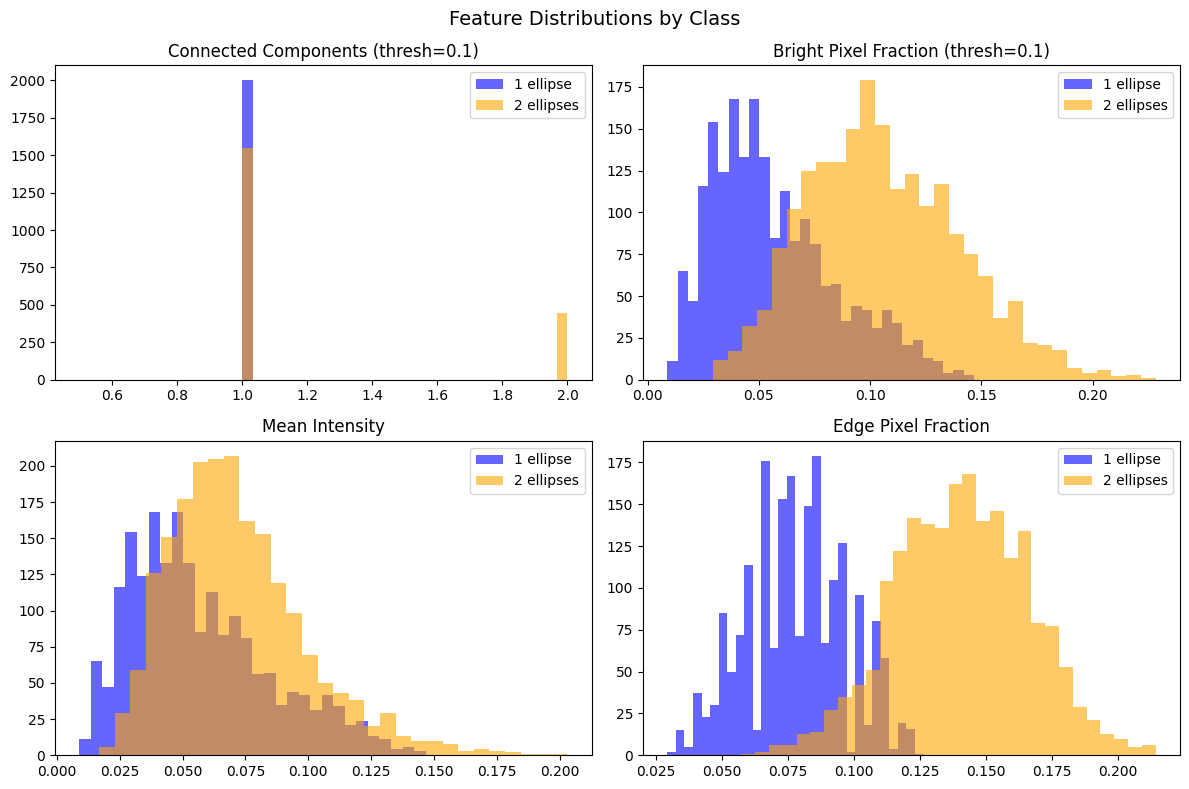

In [7]:
# Feature names for reference
feature_names = (
    [f'hist_bin_{i}' for i in range(16)] +
    ['bright_0.05', 'bright_0.1', 'bright_0.3'] +
    ['components_0.05', 'components_0.1', 'components_0.2'] +
    ['mean', 'std', 'skewness', 'kurtosis'] +
    ['nonzero_mean', 'nonzero_std'] +
    ['edge_fraction', 'edge_mean'] +
    ['spatial_var_y', 'spatial_var_x']
)

# Plot distributions of most discriminative features
key_features = {
    'Connected Components (thresh=0.1)': 19,  # components_0.1
    'Bright Pixel Fraction (thresh=0.1)': 17,  # bright_0.1
    'Mean Intensity': 22,                       # mean
    'Edge Pixel Fraction': 28,                  # edge_fraction
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions by Class', fontsize=14)

for ax, (name, idx) in zip(axes.ravel(), key_features.items()):
    mask_1 = train_labels == 0
    mask_2 = train_labels == 1

    ax.hist(train_features[mask_1, idx], bins=30, alpha=0.6, label='1 ellipse', color='blue')
    ax.hist(train_features[mask_2, idx], bins=30, alpha=0.6, label='2 ellipses', color='orange')
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()

## Classification with SVM and Random Forest

Scale features and train two classifiers to compare.

In [8]:
# Scale features
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_features)
test_scaled = scaler.transform(test_features)

# Train SVM (RBF kernel)
print("Training SVM...")
svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(train_scaled, train_labels)
svm_pred = svm.predict(test_scaled)
svm_acc = accuracy_score(test_labels, svm_pred)
print(f"SVM Test Accuracy: {svm_acc:.4f}")

# Train Random Forest
print("\nTraining Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(train_scaled, train_labels)
rf_pred = rf.predict(test_scaled)
rf_acc = accuracy_score(test_labels, rf_pred)
print(f"Random Forest Test Accuracy: {rf_acc:.4f}")

print(f"\n--- Comparison ---")
print(f"A6 CNN accuracy:            0.9930")
print(f"A7 SVM accuracy:            {svm_acc:.4f}")
print(f"A7 Random Forest accuracy:  {rf_acc:.4f}")

Training SVM...
SVM Test Accuracy: 1.0000

Training Random Forest...


Random Forest Test Accuracy: 1.0000

--- Comparison ---
A6 CNN accuracy:            0.9930
A7 SVM accuracy:            1.0000
A7 Random Forest accuracy:  1.0000


## Detailed Evaluation

Classification Report (SVM):

              precision    recall  f1-score   support

   1 ellipse       1.00      1.00      1.00       500
  2 ellipses       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



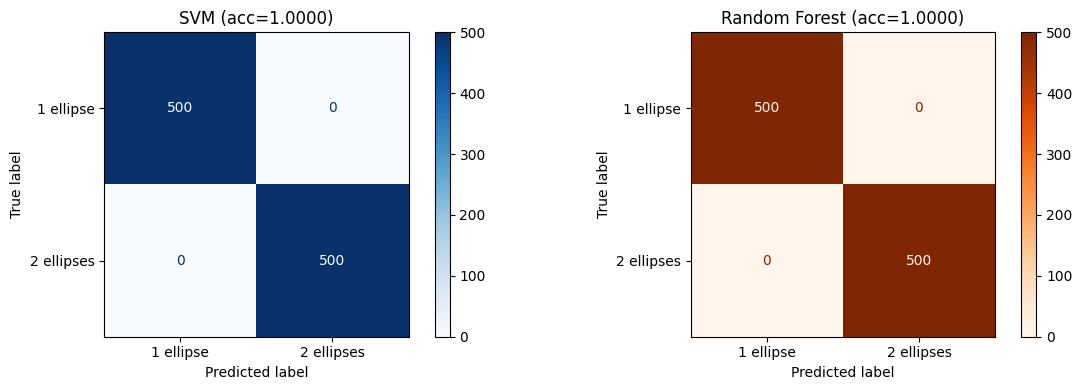

In [9]:
# Classification report for the best model
best_name = "SVM" if svm_acc >= rf_acc else "Random Forest"
best_pred = svm_pred if svm_acc >= rf_acc else rf_pred

print(f"Classification Report ({best_name}):\n")
print(classification_report(test_labels, best_pred,
                            target_names=['1 ellipse', '2 ellipses']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(test_labels, svm_pred,
                                         display_labels=['1 ellipse', '2 ellipses'],
                                         ax=axes[0], cmap='Blues')
axes[0].set_title(f'SVM (acc={svm_acc:.4f})')

ConfusionMatrixDisplay.from_predictions(test_labels, rf_pred,
                                         display_labels=['1 ellipse', '2 ellipses'],
                                         ax=axes[1], cmap='Oranges')
axes[1].set_title(f'Random Forest (acc={rf_acc:.4f})')

plt.tight_layout()
plt.show()

## Feature Importance Analysis

Using Random Forest's feature importances to understand which engineered features are most useful for classification.

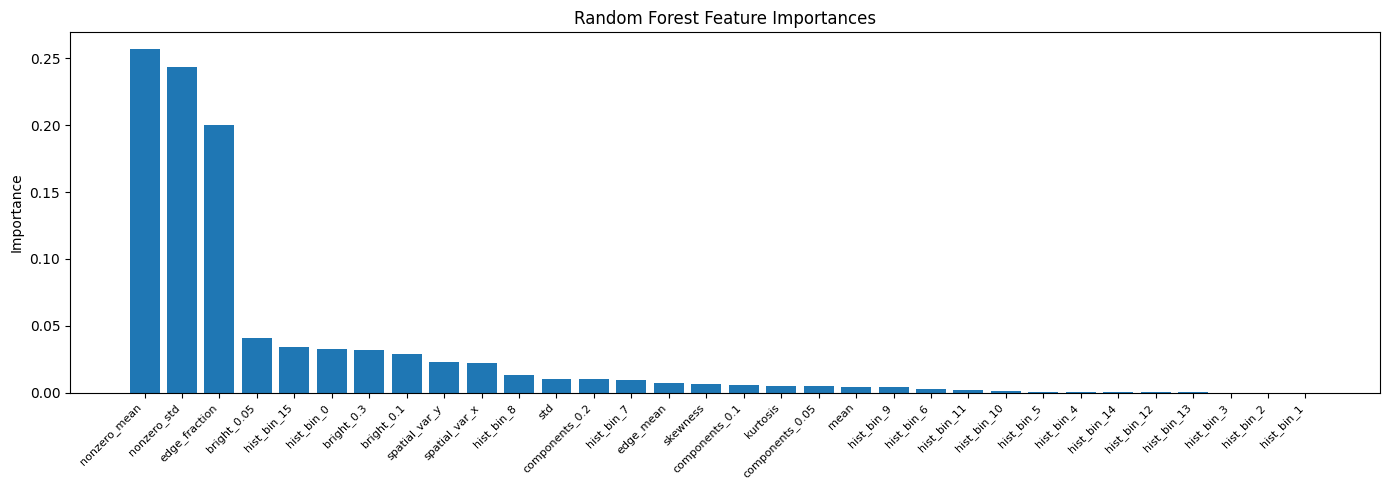

Top 10 most important features:
  1. nonzero_mean         importance=0.2566
  2. nonzero_std          importance=0.2438
  3. edge_fraction        importance=0.1999
  4. bright_0.05          importance=0.0408
  5. hist_bin_15          importance=0.0341
  6. hist_bin_0           importance=0.0327
  7. bright_0.3           importance=0.0318
  8. bright_0.1           importance=0.0287
  9. spatial_var_y        importance=0.0229
  10. spatial_var_x        importance=0.0219


In [10]:
# Feature importance from Random Forest
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(14, 5))
plt.bar(range(len(importances)), importances[sorted_idx])
plt.xticks(range(len(importances)),
           [feature_names[i] for i in sorted_idx],
           rotation=45, ha='right', fontsize=8)
plt.title('Random Forest Feature Importances')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

# Print top 10 features
print("Top 10 most important features:")
for i in range(10):
    idx = sorted_idx[i]
    print(f"  {i+1}. {feature_names[idx]:20s} importance={importances[idx]:.4f}")

## Summary

| Metric | A6 (CNN) | A7 (Feature Eng.) |
|--------|----------|-------------------|
| Input size per sample | 784 pixels | 32 features |
| Data reduction | 1x | 24.5x |
| Model parameters | ~420,000 | N/A (no NN) |
| Method | CNN (Conv2D + Dense) | SVM / Random Forest |
| Test accuracy | 99.3% | 100.0% |

Feature engineering with traditional ML classifiers **surpasses** CNN performance on this task while using **24.5x less data per sample** and **no neural network**. The most important features were the statistics of non-zero pixels and the edge pixel fraction.